# Derin Öğrenme ve Görüntü İşlemede Kırılma Noktası: ImageNet ve AlexNet

Derin öğrenme bugün görüntü işleme, doğal dil işleme, öneri sistemleri ve birçok yapay zekâ uygulamasının temelinde yer alsa da bu noktaya gelmesi bir anda olmadı. Yapay sinir ağları fikri uzun yıllardır biliniyordu; ancak geçmişte hem yeterli veri yoktu hem de bu modelleri eğitmek için gerekli hesaplama gücü oldukça sınırlıydı. Bu yüzden derin öğrenme uzun süre daha çok teorik ve akademik bir alan olarak kaldı.

Görüntü işleme tarafında uzun yıllar boyunca klasik makine öğrenmesi yöntemleri kullanıldı. Bu yaklaşımda görüntüden anlamlı özellikleri çıkarmak için insanlar tarafından tasarlanmış yöntemler kullanılırdı. Örneğin kenar bilgisi, renk histogramları, köşe noktaları veya doku bilgileri çıkarılır; daha sonra bu özellikler SVM, Random Forest veya benzeri makine öğrenmesi algoritmalarına verilirdi. Yani modelin başarısı büyük ölçüde insan eliyle tasarlanan özelliklerin kalitesine bağlıydı.

Bu noktada **ImageNet** veri seti ve **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)** yarışması önemli bir dönüm noktası oldu. ImageNet, milyonlarca etiketli görsel içeren büyük ölçekli bir görüntü veri setidir. Yaklaşık **14 milyon görsel** ve binlerce kategori içermesiyle, bilgisayarlı görü alanında büyük veri kullanımının önünü açtı.

Asıl kırılma ise 2012 yılında gerçekleşti. **Alex Krizhevsky**, **Ilya Sutskever** ve **Geoffrey Hinton** tarafından geliştirilen **AlexNet** mimarisi, ImageNet yarışmasında çok büyük bir başarı elde etti. AlexNet, derin evrişimli sinir ağları yani **Convolutional Neural Networks (CNN)** kullanarak klasik makine öğrenmesi yöntemlerine göre çok daha düşük hata oranına ulaştı.

AlexNet’in başarısında birkaç önemli unsur vardı:

- Derin CNN mimarisi kullanması
- GPU ile eğitilmesi
- Büyük miktarda veri üzerinde çalışması
- ReLU aktivasyon fonksiyonu kullanması
- Dropout gibi overfitting azaltıcı tekniklerden yararlanması
- Görüntü artırma (data augmentation) kullanması

Bu başarıdan sonra derin öğrenme, özellikle görüntü işleme alanında çok hızlı şekilde yaygınlaşmaya başladı. Daha önce teorik olarak ilgi gören derin sinir ağları, artık pratikte klasik makine öğrenmesi yöntemlerinden daha başarılı sonuçlar verebildiğini göstermiş oldu. Bu olay, endüstride de büyük bir etki yarattı. Büyük teknoloji şirketleri derin öğrenme araştırmalarına yatırım yapmaya başladı ve bilgisayarlı görü alanında yeni mimariler geliştirildi.

AlexNet’ten sonra VGG, GoogLeNet, ResNet gibi daha güçlü CNN mimarileri ortaya çıktı. Bu süreç, günümüzde kullanılan modern yapay zekâ sistemlerinin temelini oluşturdu.

Özetle, **ImageNet yarışması ve AlexNet’in 2012’deki başarısı**, derin öğrenmenin teoriden pratiğe geçtiği ve klasik makine öğrenmesi yaklaşımlarına karşı güçlü bir alternatif olduğunu kanıtladığı önemli bir kırılma noktasıdır.

# CIFAR-10 Veri Seti

**CIFAR-10**, bilgisayarlı görü ve derin öğrenme çalışmalarında sık kullanılan küçük ölçekli bir görüntü sınıflandırma veri setidir. Veri seti toplam **60.000 adet 32x32 renkli görüntüden** oluşur. Bu görüntüler **10 farklı sınıfa** ayrılmıştır.

CIFAR-10 sınıfları şunlardır:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

Veri setinde **50.000 eğitim görüntüsü** ve **10.000 test görüntüsü** bulunur. Görseller küçük boyutlu olduğu için CIFAR-10, CNN mimarilerini denemek, model eğitimi yapmak ve temel görüntü sınıflandırma problemlerini öğrenmek için oldukça uygundur.

Bu çalışmada CIFAR-10 veri seti, PyTorch `torchvision.datasets` modülü üzerinden indirilecek ve görüntü sınıflandırma problemi için kullanılacaktır.

Kaynak: https://www.cs.toronto.edu/~kriz/cifar.html

In [1]:
# Pytorch Dataset: https://docs.pytorch.org/vision/main/datasets.html

In [2]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [3]:
train_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [4]:
type(train_data[0])

tuple

In [5]:
image, label = train_data[0]

In [6]:
label

6

In [7]:
image

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [8]:
image.shape

torch.Size([3, 32, 32])

In [9]:
# color channels = 3 (RGB)
# 32 = height, 32 = width

In [10]:
len(train_data), len(test_data)

(50000, 10000)

In [11]:
class_names = train_data.classes
print(len(class_names))
class_names

10


['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Text(0.5, 1.0, 'truck')

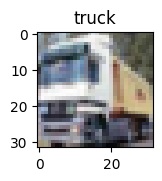

In [12]:
image, label = train_data[1]
image = image.permute(1, 2, 0) # 32 x 32 x 3
plt.figure(figsize = (1.5,1.5))
plt.imshow(image)
plt.title(class_names[label])

In [13]:
# Görüntülerin nasıl göründüğünü inceledik.
# Şimdi transforms konusunu biraz daha detaylı ele alalım.
# Çünkü çoğu durumda PIL görüntüsünü Tensor'a çevirmek tek başına yeterli değildir.
# İlerleyen aşamalarda data augmentation yöntemlerini de öğrenip transforms içine ekleyeceğiz.

from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.491, 0.482, 0.446],
                         std=[0.247, 0.243, 0.261])
])

## CIFAR-10 Görüntülerinde Normalization İşlemi

CIFAR-10 veri seti **50.000 eğitim görüntüsünden** oluşur.  
Her görüntü:

- **3 kanallıdır:** R, G, B
- **Boyutu:** 32 × 32 piksel

Bu nedenle modelin girişine verilen her görüntü aslında şu formdadır:

```text
3 × 32 × 32

In [14]:
train_data = datasets.CIFAR10(
    root="data", # Veri setinin indirileceği / saklanacağı klasör
    train=True, # Eğitim veri setini indirir
    download=True, # Veri seti daha önce indirilmediyse otomatik olarak indirir
    transform=transform, # Görüntülere uygulanacak dönüşümler
    target_transform=None # Gerekirse etiketlere de dönüşüm uygulanabilir
)

# Test veri setini hazırlıyoruz
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform # Test görüntülerine uygulanacak dönüşümler
)

Text(0.5, 1.0, 'truck')

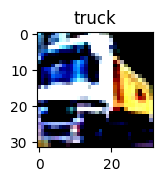

In [15]:
image, label = train_data[1]
image = image.permute(1,2,0)
plt.figure(figsize = (1.5,1.5))
plt.imshow(image)
plt.title(class_names[label])

## Normalization Model Eğitimini Nasıl Etkiler?

Normalization işlemi, görüntüleri modele vermeden önce daha uygun bir sayısal aralığa getirir.  
Bu işlem modelin öğrenmesini **bozmaz**; aksine çoğu durumda öğrenme sürecini daha düzenli ve hızlı hale getirir.

CIFAR-10 gibi görüntü veri setlerinde pikseller farklı kanallarda farklı dağılımlara sahip olabilir.  
Normalization sayesinde her kanal kendi ortalamasına ve standart sapmasına göre ölçeklendirilir.

Bu sayede:

- Model daha dengeli girişler alır
- Loss daha stabil ilerleyebilir
- Gradient akışı daha düzenli olabilir
- Optimizasyon daha hızlı yakınsayabilir
- Eğitim süresi kısalabilir

Ancak normalization tek başına modeli “daha zeki” yapmaz.  
Yani kötü bir mimariyi iyi hale getirmez veya veri setindeki problemi tek başına çözmez.

Doğru kullanıldığında normalization, modelin aynı veriden daha rahat öğrenmesini sağlar.  
Bu yüzden görüntü sınıflandırma problemlerinde genellikle standart bir ön işleme adımı olarak kullanılır.

In [16]:
# Görüntü renkleri normalize edildiği için görsel biraz farklı görünebilir.
# Ancak bu durum model eğitimi için bir problem değildir.
# Hatta çoğu durumda normalization, modelin daha sağlıklı öğrenmesine yardımcı olur.

# Şimdi DataLoader konusuna geçelim.

# DataLoader, veriyi modele daha düzenli ve kontrollü bir şekilde vermemizi sağlar.
# Veri setini küçük parçalara böler. Bu küçük parçalara batch denir.

# Genellikle tüm görüntüleri aynı anda sinir ağına vermek mümkün değildir.
# Çünkü bu işlem çok fazla bellek kullanır.

# Bu yüzden veriler batch batch modele gönderilir.
# DataLoader ayrıca verileri karıştırma, batch oluşturma ve gerekli dönüşümleri uygulama sürecini kolaylaştırır.

In [17]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32 # Batch size değiştirilebilir. 32 ve 128 sık kullanılan değerlerdir.
                # Bu değer; modeli nerede çalıştırdığına, RAM/GPU belleğine göre değişebilir.

train_dataloader = DataLoader(train_data,
    batch_size=BATCH_SIZE, # Her batch içinde kaç örnek olacağını belirtir
    shuffle=True # Eğitim verisini karıştırmak iyi bir fikirdir.
                 # Örneğin veriler sırayla 100 truck, 100 airplane şeklinde gelirse
                 # model bu sıralamadan olumsuz etkilenebilir.
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # Test verisini karıştırmak zorunda değiliz.
)

In [18]:
print(f"Train dataloader uzunluğu: {len(train_dataloader)} batch, batch size: {BATCH_SIZE}")
print(f"Test dataloader uzunluğu: {len(test_dataloader)} batch, batch size: {BATCH_SIZE}")

Train dataloader uzunluğu: 1563 batch, batch size: 32
Test dataloader uzunluğu: 313 batch, batch size: 32


In [19]:
train_dataloader.dataset[0][0].shape # Veri hâlâ dataloader içinde duruyor ve görüntünün shape değeri değişmedi.

torch.Size([3, 32, 32])

In [20]:
# Veriyi hazırladık. Şimdi modeli oluşturmamız gerekiyor.
# CNN mimarisine geçmeden önce bunu manuel olarak yapmayı deneyeceğiz.

# CNN kullanmadan çok basit bir model oluştursak bile flatten modülüne ihtiyacımız olacak.
# https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html

# Flatten, bir tensorün boyutlarını tek bir vektör haline getirir.
# Modeli oluşturmadan önce flatten işleminin ne yaptığını görelim.

flatten_model = nn.Flatten() # Bunu sadece örnek olarak kullanıyorum.
                             # Şu an bir modelin içinde değil ama yine de forward pass yapabiliriz.

first_data = train_dataloader.dataset[0][0]
flattened_data = flatten_model(first_data)

print(f"Flatten öncesi shape: {first_data.shape} -> [renk_kanalları, yükseklik, genişlik]")
print(f"Flatten sonrası shape: {flattened_data.shape} -> [renk_kanalları, yükseklik*genişlik]")

Flatten öncesi shape: torch.Size([3, 32, 32]) -> [renk_kanalları, yükseklik, genişlik]
Flatten sonrası shape: torch.Size([3, 1024]) -> [renk_kanalları, yükseklik*genişlik]


In [21]:
# Piksel verisini yükseklik ve genişlik boyutlarından çıkarıp
# uzun bir feature vector haline getirdik.

# nn.Linear() katmanları, giriş verisini feature vector formatında bekler.

In [22]:
class CIFAR10Classifier(nn.Module):
    # input_shape ve output_shape değerlerini parametre olarak alıyoruz.
    # Böylece modeli daha dinamik hale getiriyoruz.
    # Çünkü ilerleyen işlemlerde giriş/çıkış boyutlarını hesaplamamız
    # ve gerekirse ayarlamamız gerekebilir.

    # hidden_units bizim nöron sayımız olacak.
    # Bunu piksel sayısından bağımsız olarak değiştirebiliriz.
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units), # in_features = bir veri örneğindeki feature sayısı, bu örnekte piksel sayısı
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [23]:
# Peki elimizde kaç feature var?
first_data.shape

torch.Size([3, 32, 32])

In [24]:
# 3 * 32 * 32 = Toplam 3072 pikselimiz var, yani 3072 feature kullanıyoruz.
torch.manual_seed(42)

# Modeli gerekli giriş parametreleriyle oluşturuyoruz.
model_0 = CIFAR10Classifier(input_shape=3072, # Her piksel için bir giriş değeri: 3x32x32
    hidden_units=32, # Nöron sayısı
    output_shape=len(class_names) # Her sınıf için bir çıkış değeri
)

model_0 = torch.compile(model_0)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

In [25]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [26]:
torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    ### Eğitim
    train_loss = 0

    # Eğitim batch'leri üzerinde döngü kuruyoruz.
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Loss hesaplama
        loss = loss_fn(y_pred, y)
        train_loss += loss # Her batch için loss değerini epoch boyunca topluyoruz.

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Kaç örneğin işlendiğini ekrana yazdırıyoruz.
        if batch % 500 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Toplam train loss değerini batch sayısına bölerek ortalama loss hesaplıyoruz.
    train_loss /= len(train_dataloader)

    ### Test
    # Test loss ve accuracy değerlerini toplamak için değişkenleri hazırlıyoruz.
    test_loss, test_acc = 0, 0
    model_0.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:

            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Loss hesaplama
            test_loss += loss_fn(test_pred, y) # Test loss değerlerini epoch boyunca topluyoruz.

            # 3. Accuracy hesaplama
            # Tahmin edilen sınıf ile gerçek sınıf aynı mı diye kontrol ediyoruz.
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.85108 | Test loss: 1.76888, Test acc: 38.25%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.75927 | Test loss: 1.75543, Test acc: 38.92%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.74600 | Test loss: 1.76027, Test acc: 38.03%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.73286 | Test loss: 1.75780, Test acc: 38.98%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.72423 | Test loss: 1.76691, Test acc: 38.47%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

In [27]:
# Accuracy çok iyi görünmüyor.
# Ancak CNN'e geçmeden önce birkaç farklı model kurarak ilerleyeceğiz.

# Bu yüzden tüm modelleri aynı şekilde test edebilmek için
# genel bir evaluation fonksiyonu oluşturalım.
def evaluate_model_performance(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, accuracy_function):
    loss, acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_function(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Ortalama loss ve accuracy değerlerini bulmak için batch sayısına bölüyoruz.
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [28]:
model_0_results = evaluate_model_performance(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)
model_0_results

{'model_name': 'OptimizedModule',
 'model_loss': 1.7668920755386353,
 'model_acc': 38.7879392971246}

In [29]:
# Açıkça görüldüğü gibi, bu problemde sadece linear model yeterli olmuyor.
# Peki modele biraz non-linearity eklersek sonuç daha iyi olur mu?
class CIFAR10ClassifierNonLinear(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [30]:
torch.manual_seed(42)

model_1 = CIFAR10ClassifierNonLinear(input_shape=3072,
    hidden_units=32,
    output_shape=len(class_names)
)

model_1 = torch.compile(model_1)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

In [31]:
# torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    ### Eğitim
    train_loss = 0

    # Eğitim batch'leri üzerinde döngü kuruyoruz.
    for batch, (X, y) in enumerate(train_dataloader):
        model_1.train()

        # 1. Forward pass
        y_pred = model_1(X)

        # 2. Loss hesaplama
        loss = loss_fn(y_pred, y)
        train_loss += loss # Her batch için loss değerini epoch boyunca topluyoruz.

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Kaç örneğin işlendiğini ekrana yazdırıyoruz.
        if batch % 500 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Toplam train loss değerini batch sayısına bölerek ortalama loss hesaplıyoruz.
    train_loss /= len(train_dataloader)

    ### Test
    # Test loss ve accuracy değerlerini toplamak için değişkenleri hazırlıyoruz.
    test_loss, test_acc = 0, 0
    model_1.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:

            # 1. Forward pass
            test_pred = model_1(X)

            # 2. Loss hesaplama
            test_loss += loss_fn(test_pred, y) # Test loss değerlerini epoch boyunca topluyoruz.

            # 3. Accuracy hesaplama
            # Tahmin edilen sınıf ile gerçek sınıf aynı mı diye kontrol ediyoruz.
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.72454 | Test loss: 1.61981, Test acc: 43.43%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.54964 | Test loss: 1.55283, Test acc: 44.65%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.49950 | Test loss: 1.55778, Test acc: 45.58%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.45937 | Test loss: 1.51522, Test acc: 47.42%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.43066 | Test loss: 1.52448, Test acc: 46.20%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

In [32]:
model_1_results = evaluate_model_performance(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)
model_1_results

{'model_name': 'OptimizedModule',
 'model_loss': 1.4983309507369995,
 'model_acc': 48.02316293929712}

## CNN Mimarilerinin Gelişiminde Önemli Çalışmalar

Convolutional Neural Network yani **CNN** mimarileri, görüntü işleme alanında bir anda ortaya çıkmadı. Bu yapının temelleri daha eski çalışmalara dayanır.

Bu alandaki önemli erken çalışmalardan biri, **Yann LeCun ve arkadaşları** tarafından yayımlanan **“Gradient-Based Learning Applied to Document Recognition”** makalesidir. Bu çalışma, özellikle el yazısı rakam tanıma ve belge tanıma problemleri üzerinde durur. LeNet benzeri CNN yapılarıyla, görüntü verisinden anlamlı özelliklerin otomatik olarak öğrenilebileceğini göstermiştir. Bu nedenle CNN mimarilerinin pratik kullanımındaki önemli başlangıç noktalarından biri kabul edilir.

Daha sonraki yıllarda CNN mimarileri çok daha derin hale gelmiştir. **Karen Simonyan ve Andrew Zisserman** tarafından yayımlanan **“Very Deep Convolutional Networks for Large-Scale Image Recognition”** çalışması, bu gelişimin önemli örneklerinden biridir. Bu makalede, ağ derinliğinin görüntü sınıflandırma başarısı üzerindeki etkisi incelenmiştir. VGG olarak bilinen bu mimaride küçük boyutlu **3×3 convolution filtreleri** kullanılarak 16-19 katmanlı daha derin ağlar oluşturulmuştur.

Bu iki çalışma, CNN’lerin gelişimini anlamak için önemli bir çizgi oluşturur:

- LeCun’un çalışması, CNN’lerin belge ve rakam tanıma gibi pratik problemlerde kullanılabileceğini göstermiştir.
- VGG çalışması ise daha derin CNN mimarilerinin büyük ölçekli görüntü tanıma problemlerinde daha güçlü sonuçlar verebileceğini göstermiştir.

Kısacası, CNN mimarileri önce belge tanıma gibi daha sınırlı problemlerle pratik değerini göstermiş, daha sonra ImageNet gibi büyük ölçekli veri setleriyle modern görüntü sınıflandırma problemlerinde çok güçlü hale gelmiştir.

In [33]:
# Görüldüğü gibi sonuç çok fazla iyileşmedi.

# Peki accuracy değerini nasıl artırabiliriz?
# Daha iyi transforms, daha iyi bir model, daha fazla katman,
# daha fazla nöron, daha iyi veri gibi seçenekler denenebilir.

# Ancak CNN mimarisi, aynı veri ve benzer ayarlarla
# görüntüler için daha uygun bir katman yapısı sağlar.
# Şimdi bunu deneyelim.

# https://poloclub.github.io/cnn-explainer/

# Input layer -> [Convolutional layer -> activation layer -> pooling layer] -> Output layer

# Bu CNN explainer sitesi TinyVGG CNN mimarisini kullanıyor.
# Biz de buna benzer bir yapı kurmayı deneyelim.
class CIFAR10ClassifierCNN(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # ya da = (3,3) -> Görüntü üzerinde gezen karenin boyutu
                      stride=1, # Varsayılan değer
                      padding=1), # Seçenekler: "valid" padding yok, "same" çıktı boyutu aynı kalır veya belirli bir int değer verilebilir
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # Varsayılan stride değeri genelde kernel_size ile aynıdır.
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # Bu in_features değeri nereden geldi?
            # Ağdaki her katman giriş verisinin shape değerini sıkıştırır ve değiştirir.
            nn.Linear(in_features=hidden_units*8*8,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.block_2(self.block_1(x)))

In [34]:
# CNN Deep Dive: https://github.com/atilsamancioglu/DeepLearningBootcamp/blob/main/11-CNNDeepDive.ipynb

In [35]:
# torch.manual_seed(42)

model_2 = CIFAR10ClassifierCNN(input_shape=3, # 3 renk kanalı
    hidden_units=32,
    output_shape=len(class_names))

model_2

CIFAR10ClassifierCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)

In [36]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=0.001)

# torch.manual_seed(42)

epochs = 10

for epoch in range(epochs):

    ### Eğitim
    train_loss = 0

    # Eğitim batch'leri üzerinde döngü kuruyoruz.
    for batch, (X, y) in enumerate(train_dataloader):
        model_2.train()

        # 1. Forward pass
        y_pred = model_2(X)

        # 2. Loss hesaplama
        loss = loss_fn(y_pred, y)
        train_loss += loss # Her batch için loss değerini epoch boyunca topluyoruz.

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Kaç örneğin işlendiğini ekrana yazdırıyoruz.
        if batch % 500 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Toplam train loss değerini batch sayısına bölerek ortalama loss hesaplıyoruz.
    train_loss /= len(train_dataloader)

    ### Test
    # Test loss ve accuracy değerlerini toplamak için değişkenleri hazırlıyoruz.
    test_loss, test_acc = 0, 0
    model_2.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:

            # 1. Forward pass
            test_pred = model_2(X)

            # 2. Loss hesaplama
            test_loss += loss_fn(test_pred, y) # Test loss değerlerini epoch boyunca topluyoruz.

            # 3. Accuracy hesaplama
            # Tahmin edilen sınıf ile gerçek sınıf aynı mı diye kontrol ediyoruz.
            test_acc += calculate_accuracy(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 1.36125 | Test loss: 1.10275, Test acc: 60.52%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.96297 | Test loss: 0.94455, Test acc: 66.69%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.82003 | Test loss: 0.89159, Test acc: 69.01%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.73200 | Test loss: 0.78975, Test acc: 72.71%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

Train loss: 0.67249 | Test loss: 0.79476, Test acc: 73.00%

Looked at 0/50000 samples
Looked at 16000/50000 samples
Looked at 32000/50000 samples
Looked at 48000/50000 samples

In [37]:
model_2_results = evaluate_model_performance(model=model_2, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_function=calculate_accuracy)
model_2_results

{'model_name': 'CIFAR10ClassifierCNN',
 'model_loss': 0.820952296257019,
 'model_acc': 73.91174121405751}

In [38]:
# Görüldüğü gibi accuracy değeri artık çok daha iyi görünüyor.

# Şimdi model_2 ile bazı tahminler yapalım.
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # Her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits değerlerini al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Tüm tahminleri birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [39]:
import random

def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()

    plt.figure(figsize=(4, 4))

    # Rastgele 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # Görüntüyü modele uygun hale getir
            img_input = img.unsqueeze(0)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # Görseli çizdirmek için boyutları düzenle
            img_show = img.permute(1, 2, 0)

            # Tahmin doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # Subplot oluştur
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

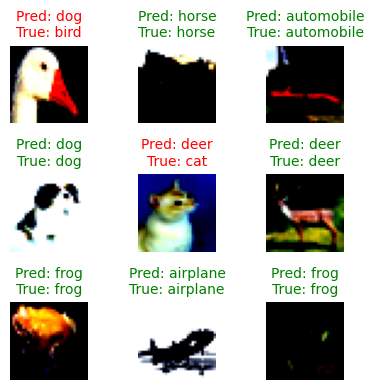

In [40]:
show_random_predictions(model_2, test_data, class_names)

In [41]:
# Accuracy değerini artırmak istersen, 0.01 yerine 0.001 learning rate deneyebilirsin.

# Ayrıca stride, kernel_size, padding gibi hiperparametreleri değiştirerek
# sonucun nasıl etkilendiğini gözlemleyebilirsin.